# Introduction to Deep Learning & Neural Networks Fundamentals

## Learning Objectives
- Understand what deep learning is and its applications
- Learn the basic building blocks of neural networks
- Understand activation functions and their importance
- Implement a simple neural network from scratch using NumPy

## 1.1 What is Deep Learning?

Deep Learning is a subset of machine learning that uses neural networks with multiple layers (deep neural networks) to progressively extract higher-level features from raw input. It's inspired by the structure and function of the human brain.

### Key Applications:
- Computer Vision (image recognition, object detection)
- Natural Language Processing (translation, sentiment analysis)
- Speech Recognition
- Recommendation Systems
- Autonomous Vehicles

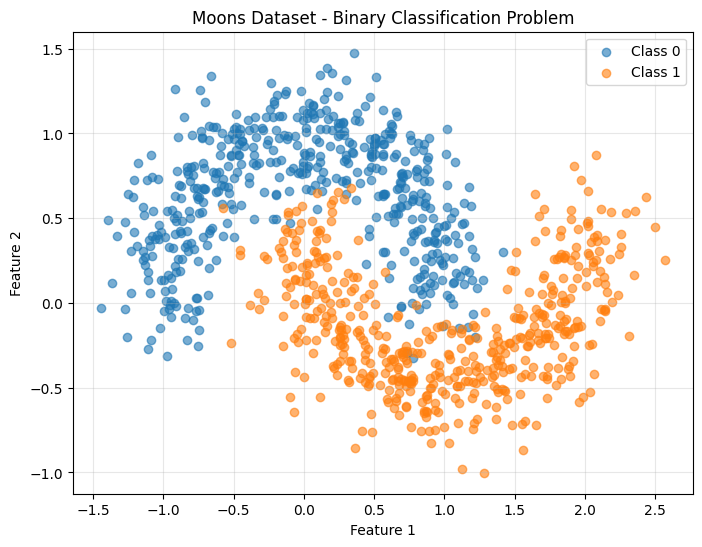

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Generate a sample dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], label='Class 0', alpha=0.6)
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label='Class 1', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Moons Dataset - Binary Classification Problem')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
X.shape

(1000, 2)

In [4]:
X

array([[-0.11166654,  0.52022374],
       [ 1.14264982, -0.34257734],
       [ 0.79555796, -0.01144231],
       ...,
       [ 1.72760808, -0.42882943],
       [-1.01448644,  0.13522904],
       [ 0.77438101,  0.63428493]])

In [5]:
y


array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [6]:
X[0]

array([-0.11166654,  0.52022374])

In [7]:
y[0]

1

In [3]:
y.shape

(1000,)

## 1.2 The Perceptron: Building Block of Neural Networks

A perceptron is the simplest form of a neural network. It takes inputs, applies weights, adds a bias, and passes through an activation function.

### Mathematical Formulation:
$$output = activation(\sum_{i=1}^n w_i x_i + b)$$

![Description of Image](perceptron.jpg)

In [ ]:
#hidden layer
Hidden layers :

Layer 1:

Detect edges

Detect colors

Layer 2:

Detect shapes

Detect textures

Layer 3:

Detect ears, eyes

Then the output layer says:
 “This is a cat.”

In [8]:
class Perceptron:
    """Simple Perceptron implementation"""
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        
    def activation(self, x):
        """Step activation function"""
        return 1 if x >= 0 else 0
    
    def fit(self, X, y):
        """Train the perceptron"""
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Training loop
        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation(linear_output)
                
                # Update weights and bias
                update = self.lr * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update
    
    def predict(self, X):
        """Make predictions"""
        linear_output = np.dot(X, self.weights) + self.bias
        return np.array([self.activation(x) for x in linear_output])

# Test the perceptron
perceptron = Perceptron(learning_rate=0.01, n_iterations=1000)
perceptron.fit(X_train, y_train)

# Make predictions
y_pred = perceptron.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Perceptron Accuracy: {accuracy:.4f}")



Perceptron Accuracy: 0.8500


In [15]:
predict_ = perceptron.predict([[2,0.4]])
print(predict_)

[1]


In [11]:
X[0]

array([-0.11166654,  0.52022374])

## 1.3 Activation Functions

Activation functions introduce non-linearity into neural networks, allowing them to learn complex patterns.

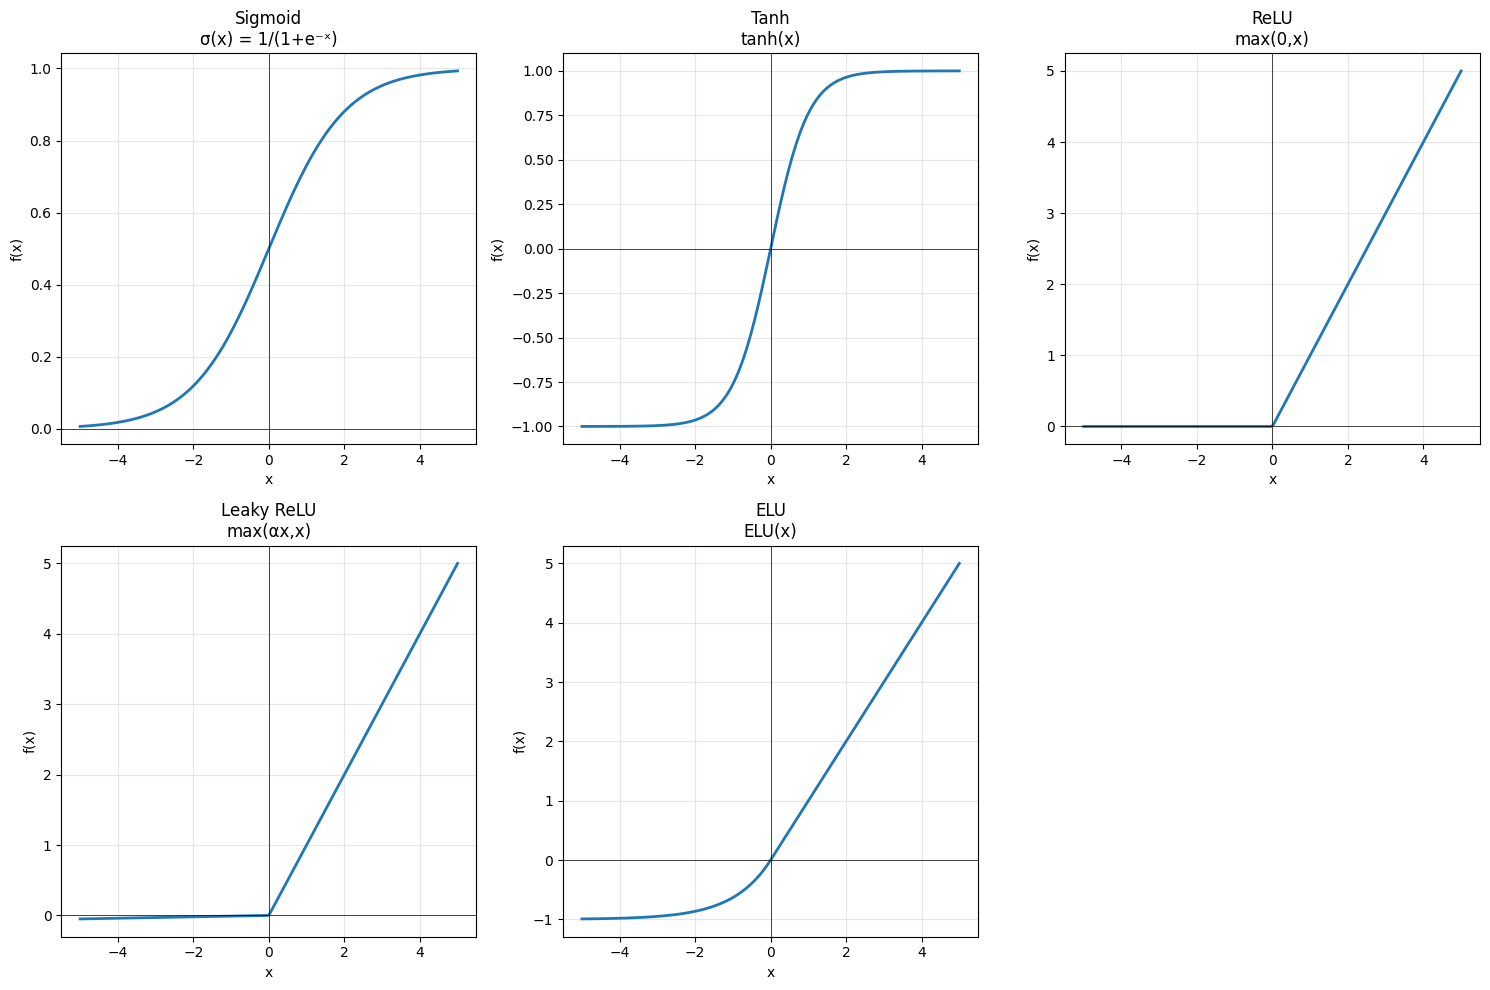


Activation Function Properties:
Sigmoid: Smooth, bounded (0,1), suffers from vanishing gradient
Tanh: Smooth, bounded (-1,1), zero-centered, suffers from vanishing gradient
ReLU: Computationally efficient, sparse activation, can cause dying neurons
Leaky ReLU: Addresses dying ReLU problem
ELU: Smooth, negative values allow mean activations near zero


In [9]:
# Define common activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

# Generate x values
x = np.linspace(-5, 5, 200)

# Plot activation functions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

activations = [
    (sigmoid, 'Sigmoid', 'σ(x) = 1/(1+e⁻ˣ)'),
    (tanh, 'Tanh', 'tanh(x)'),
    (relu, 'ReLU', 'max(0,x)'),
    (leaky_relu, 'Leaky ReLU', 'max(αx,x)'),
    (elu, 'ELU', 'ELU(x)')
]

for idx, (func, name, formula) in enumerate(activations):
    axes[idx].plot(x, func(x), linewidth=2)
    axes[idx].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[idx].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_title(f'{name}\n{formula}')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('f(x)')

# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

# Print derivative information
print("\nActivation Function Properties:")
print("Sigmoid: Smooth, bounded (0,1), suffers from vanishing gradient")
print("Tanh: Smooth, bounded (-1,1), zero-centered, suffers from vanishing gradient")
print("ReLU: Computationally efficient, sparse activation, can cause dying neurons")
print("Leaky ReLU: Addresses dying ReLU problem")
print("ELU: Smooth, negative values allow mean activations near zero")

## 1.4 Building a Neural Network from Scratch

Let's implement a simple neural network with one hidden layer using NumPy. This will help us understand the forward and backward propagation processes.

In [16]:
class NeuralNetwork:
    """Simple Neural Network with one hidden layer"""
    
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.lr = learning_rate
        
        # Initialize weights and biases with small random values
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
        
    def sigmoid(self, x):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-np.clip(x, -250, 250)))  # Clip to prevent overflow
    
    def sigmoid_derivative(self, x):
        """Derivative of sigmoid function"""
        return x * (1 - x)
    
    def forward(self, X):
        """Forward propagation"""
        # First layer
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        
        # Second layer (output layer)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2
    
    def backward(self, X, y, output):
        """Backward propagation"""
        m = X.shape[0]
        
        # Calculate gradients
        # Output layer gradients
        dZ2 = output - y.reshape(-1, 1)
        dW2 = (1/m) * np.dot(self.a1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
        
        # Hidden layer gradients
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.sigmoid_derivative(self.a1)
        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
        
        # Update parameters using gradient descent
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        
        # Return gradients for monitoring (optional)
        return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
    
    def compute_loss(self, y_true, y_pred):
        """Compute binary cross-entropy loss"""
        # Add small epsilon to avoid log(0)
        epsilon = 1e-8
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    def train(self, X, y, epochs=1000, verbose=True):
        """Train the neural network"""
        losses = []
        
        for epoch in range(epochs):
            # Forward propagation
            output = self.forward(X)
            
            # Calculate loss
            loss = self.compute_loss(y, output)
            losses.append(loss)
            
            # Backward propagation
            self.backward(X, y, output)
            
            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.6f}")
        
        return losses
    
    def predict(self, X):
        """Make predictions (returns probabilities)"""
        output = self.forward(X)
        return output
    
    def predict_classes(self, X, threshold=0.5):
        """Make class predictions"""
        output = self.forward(X)
        return (output > threshold).astype(int)

# Create and train the neural network
nn = NeuralNetwork(input_size=2, hidden_size=10, output_size=1, learning_rate=0.1)

print("Training Neural Network...")
losses = nn.train(X_train, y_train, epochs=2000, verbose=True)

Training Neural Network...
Epoch 0, Loss: 0.693160
Epoch 100, Loss: 0.693147
Epoch 200, Loss: 0.693148
Epoch 300, Loss: 0.693169
Epoch 400, Loss: 0.693614
Epoch 500, Loss: 0.700277
Epoch 600, Loss: 0.742480
Epoch 700, Loss: 0.835287
Epoch 800, Loss: 0.936545
Epoch 900, Loss: 1.020119
Epoch 1000, Loss: 1.084838
Epoch 1100, Loss: 1.135980
Epoch 1200, Loss: 1.178239
Epoch 1300, Loss: 1.214466
Epoch 1400, Loss: 1.246066
Epoch 1500, Loss: 1.273675
Epoch 1600, Loss: 1.297644
Epoch 1700, Loss: 1.318271
Epoch 1800, Loss: 1.335878
Epoch 1900, Loss: 1.350807


![Description of Image](hidden_layer.png)

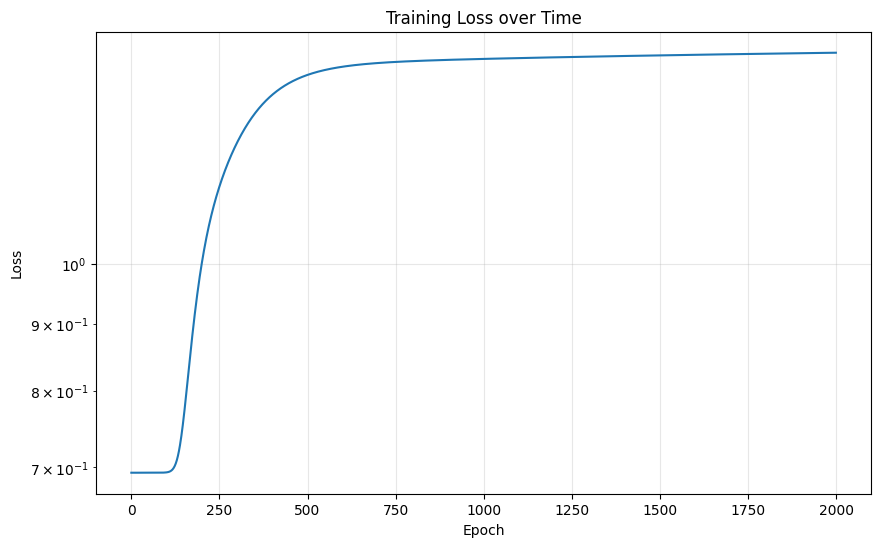

In [21]:
# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale to see small losses better
plt.show()

In [22]:
# Evaluate the model
y_pred_proba = nn.predict(X_test)
y_pred = nn.predict_classes(X_test).flatten()
accuracy = np.mean(y_pred == y_test)
print(f"\nNeural Network Accuracy: {accuracy:.4f}")

# Print sample predictions
print("\nSample Predictions:")
for i in range(5):
    print(f"Sample {i+1}: True={y_test[i]}, Predicted={y_pred[i]}, Probability={y_pred_proba[i][0]:.4f}")


Neural Network Accuracy: 0.8600

Sample Predictions:
Sample 1: True=1, Predicted=1, Probability=0.9646
Sample 2: True=0, Predicted=0, Probability=0.4323
Sample 3: True=1, Predicted=1, Probability=0.9778
Sample 4: True=0, Predicted=0, Probability=0.0559
Sample 5: True=1, Predicted=1, Probability=0.9872


In [31]:
import numpy as np

new_data = np.random.rand(5, 2)
print("New data:")
print(new_data)

New data:
[[0.74604488 0.58336877]
 [0.96217255 0.37487058]
 [0.28571209 0.86859913]
 [0.22359584 0.96322254]
 [0.01215447 0.96987883]]


In [32]:
# Get predicted probabilities
predicted_proba = nn.predict(new_data)
print("\nPredicted probabilities:")
print(predicted_proba)


Predicted probabilities:
[[0.21020178]
 [0.48899646]
 [0.04336267]
 [0.02901541]
 [0.02306082]]


In [33]:

predicted_classes = nn.predict_classes(new_data)
print("\nPredicted classes:")
print(predicted_classes)


Predicted classes:
[[0]
 [0]
 [0]
 [0]
 [0]]


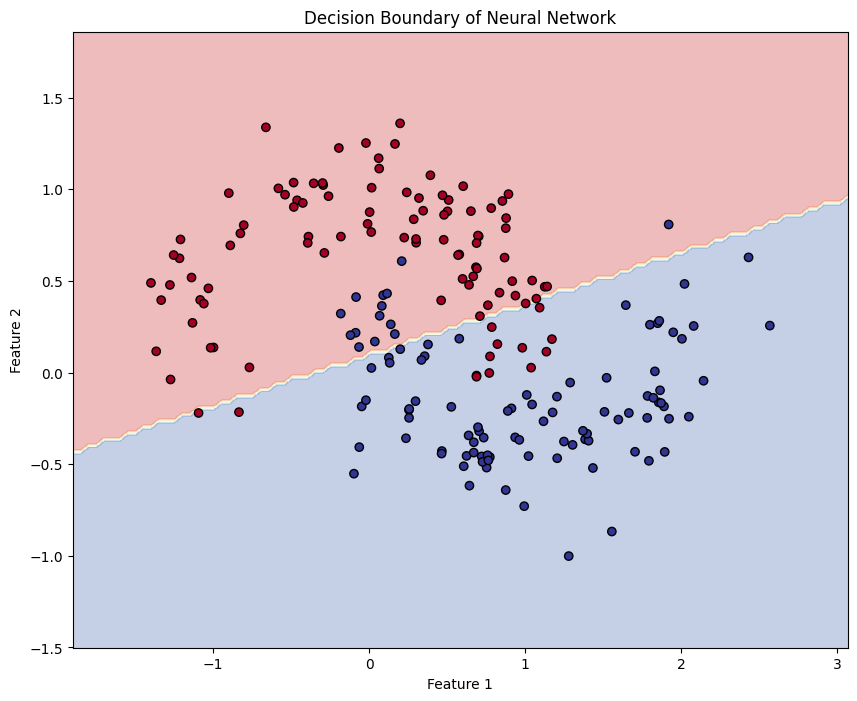

In [23]:
# Visualize decision boundary
def plot_decision_boundary(model, X, y):
    """Plot decision boundary of the model"""
    # Create mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Predict on mesh points
    Z = model.predict_classes(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='black')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary of Neural Network')
    plt.show()

plot_decision_boundary(nn, X_test, y_test)

## 1.5 Understanding the Learning Process

Let's visualize how the neural network learns over time by looking at the decision boundary at different stages of training.

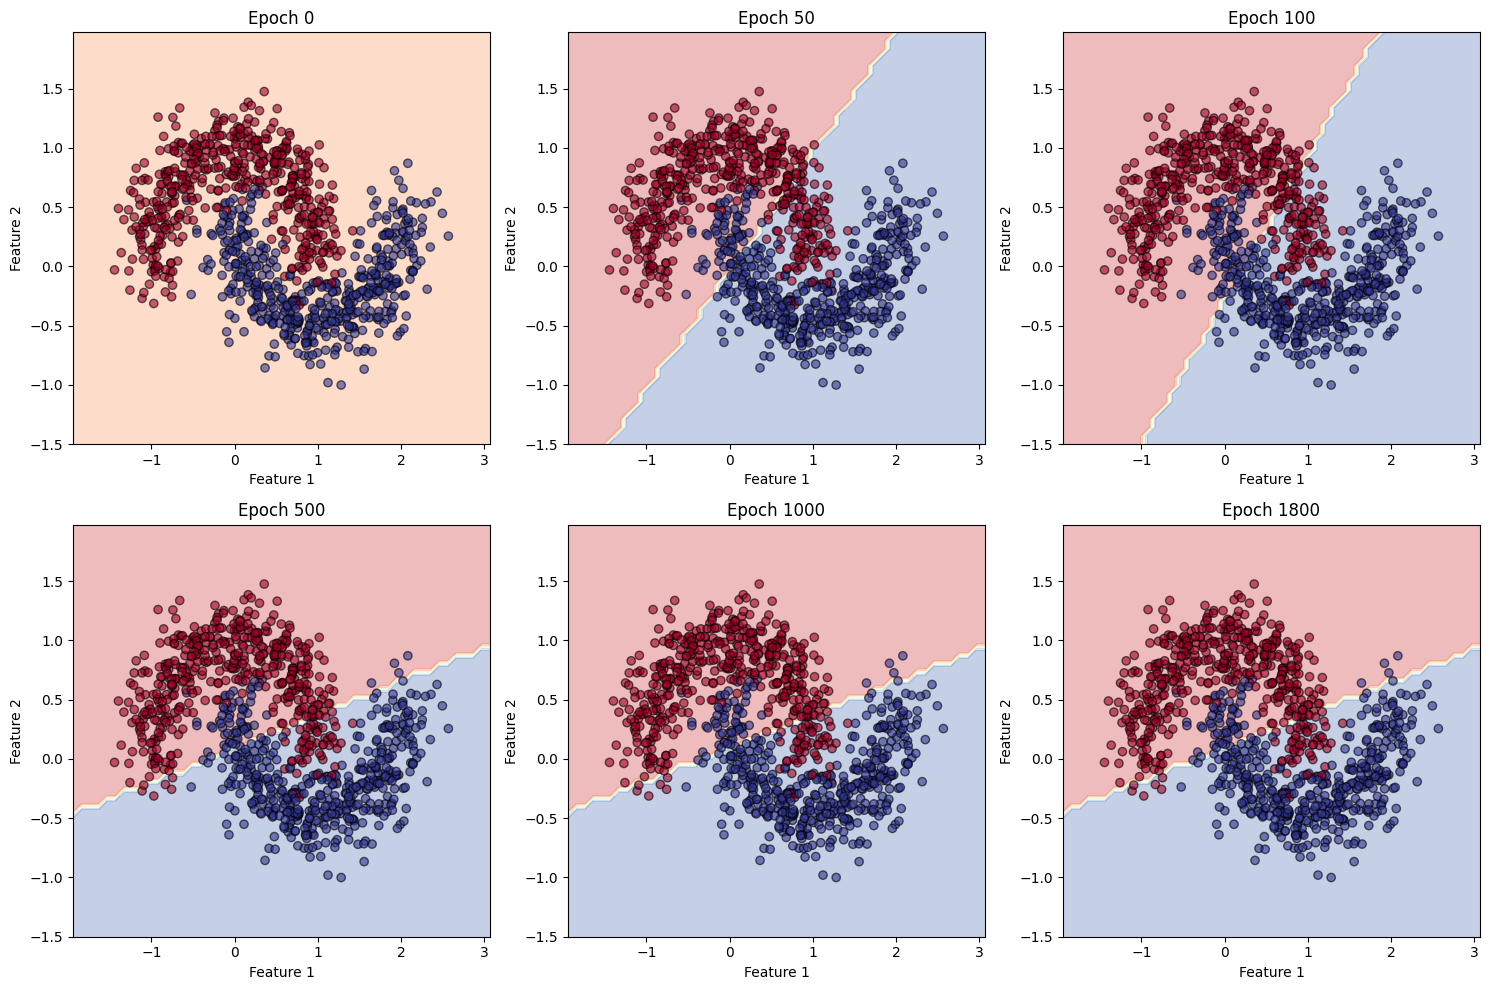

In [25]:
# Train a new network and capture intermediate states
nn_viz = NeuralNetwork(input_size=2, hidden_size=10, output_size=1, learning_rate=0.5)

# Train for a few epochs and capture decision boundaries
epochs_to_capture = [0, 50, 100, 500, 1000,1800]
decision_boundaries = []

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, epoch in enumerate(epochs_to_capture):
    if epoch > 0:
        # Train up to this epoch
        nn_viz.train(X_train, y_train, epochs=epoch - (epochs_to_capture[idx-1] if idx > 0 else 0), verbose=False)
    
    # Create mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50))
    
    # Predict on mesh points
    Z = nn_viz.predict_classes(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    axes[idx].scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='black', alpha=0.6)
    axes[idx].set_title(f'Epoch {epoch}')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

## 1.6 Key Concepts Summary

### Neural Network Components:
1. **Input Layer**: Receives the raw data
2. **Hidden Layers**: Learn features and patterns
3. **Output Layer**: Produces the final prediction
4. **Weights**: Learnable parameters that determine importance of inputs
5. **Biases**: Learnable parameters that shift the activation

### Training Process:
1. **Forward Propagation**: Compute predictions
2. **Loss Calculation**: Measure prediction error
3. **Backward Propagation**: Compute gradients
4. **Parameter Update**: Adjust weights using gradient descent

### Important Concepts:
- **Non-linearity**: Essential for learning complex patterns (provided by activation functions)
- **Vanishing Gradient**: Problem in deep networks where gradients become very small
- **Learning Rate**: Controls step size during gradient descent
- **Epochs**: Number of passes through the entire dataset